# 호텔 예약 취소 개선 방안을 위한 원인 분석 및 전략 제안
# (City Hotel, Resort Hotel )

## 공통 영역
- class import, 전역변수, 함수 선언

### MyDrive에 데이터 파일 업로드 하기....

In [ ]:
# # colab 사용하시는 분들만!!!!
# # 아래 코드 주석 해제해서 돌리셈

# import os
# os.makedirs('data', exist_ok=True)

# from google.colab import files
# uploaded = files.upload()   # 파일 선택창이 뜹니다

# # 업로드된 파일을 data/ 로 옮기기
# for name in uploaded:
#     os.rename(name, f'data/{name}')

# print(os.listdir('data'))
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Colab 한글 폰트 설정
import matplotlib.font_manager as fm

# 기본설정
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)

# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
# fm.fontManager.addfont(font_path)

# font_name = fm.FontProperties(fname=font_path).get_name()

# plt.rcParams["font.family"] = font_name
# plt.rcParams["axes.unicode_minus"] = False



plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False



# Constant
FILE_NAME = "data/hotel_data_modified.csv"

df_raw =  pd.read_csv(
    FILE_NAME,
    sep=",",
    encoding="utf-8",
    header=0,
    index_col=None,
    na_values=["-", "없음", "N/A"]
)

In [15]:
# df_raw.shape
# df_raw.info()
# df_raw.describe()
# df_raw.duplicated().sum()
# df_raw["hotel"].value_counts()

df_raw.groupby(["hotel"])["is_canceled"].describe()
# df_raw.groupby("hotel")["is_canceled"].value_counts(normalize=True)
# df_raw.isna().sum()


,count,mean,std,min,25%,50%,75%,max
hotel,,,,,,,,
City Hotel,79330.0,0.417270,0.493111,0.0,0.0,0.0,1.0,1.0
Resort Hotel,40060.0,0.277634,0.447837,0.0,0.0,0.0,1.0,1.0


In [ ]:

df_raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03


In [ ]:
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()}개")

hotel: 2개
is_canceled: 2개
lead_time: 479개
arrival_date_year: 3개
arrival_date_month: 12개
arrival_date_week_number: 53개
arrival_date_day_of_month: 31개
stays_in_weekend_nights: 17개
stays_in_week_nights: 35개
adults: 14개
children: 5개
babies: 5개
meal: 5개
country: 177개
market_segment: 8개
distribution_channel: 5개
is_repeated_guest: 2개
previous_cancellations: 15개
previous_bookings_not_canceled: 73개
reserved_room_type: 10개
assigned_room_type: 12개
booking_changes: 21개
agent: 333개
company: 352개
days_in_waiting_list: 128개
required_car_parking_spaces: 5개
total_of_special_requests: 6개
reservation_status: 3개
reservation_status_date: 926개


In [ ]:
def hotel_factor_summary(df, factor, hotel_baseline, min_reservation_rate=5):
    """
    단일 factor  취소 데이터 추출
    Args:
        df(DataFrame), factor(str), hotel_baseline([list]), min_reservation_rate(num) 
	Returns:
        DataFrame 
    """
    summary = (
        df
        .groupby(["hotel", factor])["is_canceled"]
        .agg(
            reservation_count="count",
            cancel_count="sum"
        )
    )

    # 그룹별 취소율
    summary["cancel_rate"] = (
        summary["cancel_count"]
        / summary["reservation_count"]
        * 100
    ).round(2)

    # 호텔 Baseline 취소율
    summary["hotel_baseline_rate"] = (
        summary.index
        .get_level_values("hotel")
        .map(hotel_baseline["cancel_rate"])
    )

    # Baseline 대비 취소율 차이
    summary["cancel_rate_diff"] = (
        summary["cancel_rate"]
        - summary["hotel_baseline_rate"]
    ).round(2)

    # 호텔 내 예약 비중
    summary["reservation_rate"] = (
        summary["reservation_count"]
        /
        summary.index
        .get_level_values("hotel")
        .map(hotel_baseline["reservation_count"])
        * 100
    ).round(2)

    # 예약비중 5% 이하 제외
    summary = summary[
        summary["reservation_rate"] > min_reservation_rate
    ]

    return summary

In [ ]:
def hotel_two_factor_summary( df, factor1, factor2, hotel_baseline=None, min_reservation_rate=0 ):
    """
    2개 factor  취소 데이터 추출
    Args:
        df(DataFrame), factor1(str), factor2(str), hotel_baseline([list]), min_reservation_rate(num)
    Returns: 
        DataFrame 
	"""

    summary = (
        df.groupby(["hotel", factor1, factor2])["is_canceled"]
        .agg(
            reservation_count="count",
            cancel_count="sum"
        )
    )

    summary["cancel_rate"] = (
        summary["cancel_count"]
        / summary["reservation_count"]
        * 100
    ).round(2)

    # 호텔별 전체 취소율을 직접 계산
    hotel_rate = (
        df.groupby("hotel")["is_canceled"]
        .mean()
        * 100
    )

    # 호텔 기준 취소율 연결
    summary["hotel_baseline_rate"] = (
        summary.index
        .get_level_values("hotel")
        .map(hotel_rate)
        .round(2)
    )

    summary["cancel_rate_diff"] = (
        summary["cancel_rate"]
        - summary["hotel_baseline_rate"]
    ).round(2)

    # 호텔별 예약 비중
    summary["reservation_rate"] = (
        summary["reservation_count"]
        / summary.groupby(level="hotel")["reservation_count"]
        .transform("sum")
        * 100
    ).round(2)

    # 예약 비중 필터
    summary = summary[
        summary["reservation_rate"] >= min_reservation_rate
    ]

    return summary

In [ ]:
# 기초자료 : 전체예약건수, 전체취소건수, 전체예약대비취소율 베이스정보 생성(기준값 또는 이상치 기초자료로 사용)
baseline = (
    df_raw["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)

baseline["cancel_rate"] = (
    baseline["cancel_count"]
    / baseline["reservation_count"]
    * 100
).round(2)

#baseline
hotel_baseline = (
    df_raw
    .groupby("hotel")["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)

# 2) 호텔별
hotel_baseline["cancel_rate"] = (
    hotel_baseline["cancel_count"]
    / hotel_baseline["reservation_count"]
    * 100
).round(2)

hotel_baseline


,reservation_count,cancel_count,cancel_rate
hotel,,,
City Hotel,79330,33102,41.73
Resort Hotel,40060,11122,27.76


## 데이터전처리
- 데이터 전처리 (중복, 결측치)
 - 중복 기준은 산정하기 힘듦 (PK 없음)
 - 결측치 체크
    agent, company 결측치 높음
  children	4	0.00
  country	488	0.41
  agent	16340	13.69
  company	112593	94.31

### 단위 factor 별 예약대비 취소율 영향도 평가
- 단위 factor 분석결과 영향도 적은 건은 제외하였음
- lead_time, market_segment 항목에서 영향도가 높아 분석기초자료로 사용
- PRT + Group ( country + market_segment ) 취소율이 평균치보다 높아 두 그룹으로 나누어서 비교 분석 권고 (힘들어서 안함)

In [ ]:
# market_segment
# City hotel 그룹 취소건이 높아 추가 분석필요
# Online TA/Offline TA/TO 취소정보 확인필요
market_summary = hotel_factor_summary(
    df_raw,
    "market_segment",
    hotel_baseline,
    min_reservation_rate=0
)

market_summary

reservation_count  cancel_count  cancel_rate  \
hotel        market_segment                                                 
City Hotel   Aviation                      237            52        21.94   
             Complementary                 542            64        11.81   
             Corporate                    2986           641        21.47   
             Direct                       6093          1056        17.33   
             Groups                      13975          9623        68.86   
             Offline TA/TO               16747          7173        42.83   
             Online TA                   38748         14491        37.40   
Resort Hotel Complementary                 201            33        16.42   
             Corporate                    2309           351        15.20   
             Direct                       6513           878        13.48   
             Groups                       5836          2474        42.39   
             Offline TA/TO                7472          1138        15.23   
             Online TA                   17729          6248        35.24   

                             hotel_baseline_rate  cancel_rate_diff  \
hotel        market_segment                                          
City Hotel   Aviation                      41.73            -19.79   
             Complementary                 41.73            -29.92   
             Corporate                     41.73            -20.26   
             Direct                        41.73            -24.40   
             Groups                        41.73             27.13   
             Offline TA/TO                 41.73              1.10   
             Online TA                     41.73             -4.33   
Resort Hotel Complementary                 27.76            -11.34   
             Corporate                     27.76            -12.56   
             Direct                        27.76            -14.28   
             Groups                        27.76             14.63   
             Offline TA/TO                 27.76            -12.53   
             Online TA                     27.76              7.48   

                             reservation_rate  
hotel        market_segment                    
City Hotel   Aviation                    0.30  
             Complementary               0.68  
             Corporate                   3.76  
             Direct                      7.68  
             Groups                     17.62  
             Offline TA/TO              21.11  
             Online TA                  48.84  
Resort Hotel Complementary               0.50  
             Corporate                   5.76  
             Direct                     16.26  
             Groups                     14.57  
             Offline TA/TO              18.65  
             Online TA                  44.26

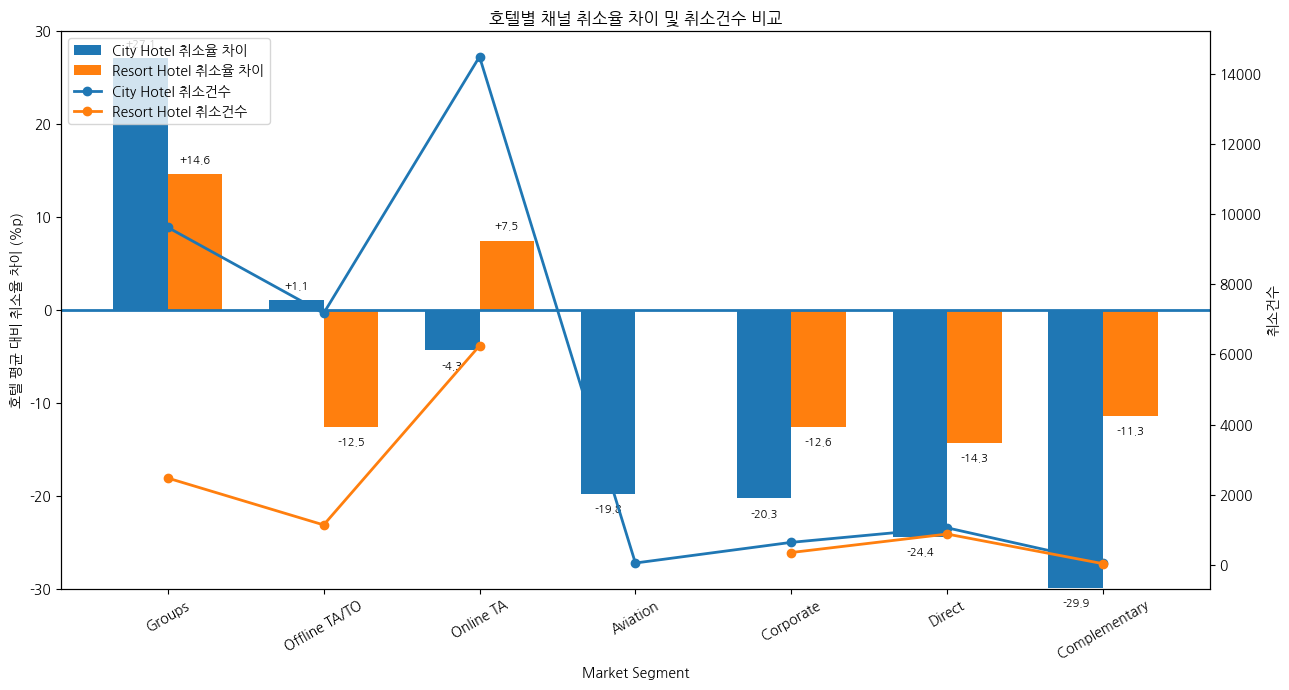

In [ ]:
# ------------------------------------------------------------
# market_segment : 그래프
# ------------------------------------------------------------
plot_data = (
    market_summary
    .reset_index()
    .pivot(
        index="market_segment",
        columns="hotel",
        values=["cancel_rate_diff", "cancel_count"]
    )
)

# 컬럼 정리
plot_data.columns = [
    f"{col[1]}_{col[0]}"
    for col in plot_data.columns
]


# 취소율 차이 기준 정렬
sort_cols = [
    "City Hotel_cancel_rate_diff",
    "Resort Hotel_cancel_rate_diff"
]

plot_data = plot_data.sort_values(
    by=sort_cols,
    ascending=False
)


# ------------------------------------------------------------
# 그래프
# ------------------------------------------------------------
x = np.arange(len(plot_data.index))
width = 0.35

fig, ax1 = plt.subplots(figsize=(13, 7))


# ============================================================
# ① 막대 : 호텔 평균 대비 취소율 차이
# ============================================================

bars1 = ax1.bar(
    x - width / 2,
    plot_data["City Hotel_cancel_rate_diff"],
    width,
    label="City Hotel 취소율 차이"
)

bars2 = ax1.bar(
    x + width / 2,
    plot_data["Resort Hotel_cancel_rate_diff"],
    width,
    label="Resort Hotel 취소율 차이"
)


# 기준선 = 0
ax1.axhline(
    0,
    linewidth=2
)


# ============================================================
# ② 막대 값 표시
# ============================================================

for bars in [bars1, bars2]:

    for bar in bars:

        value = bar.get_height()

        if np.isnan(value):
            continue

        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            value + (1 if value >= 0 else -1),
            f"{value:+.1f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=8
        )


# ============================================================
# ③ 오른쪽 Y축 생성
# ============================================================

ax2 = ax1.twinx()


# City Hotel 취소건수
line1 = ax2.plot(
    x,
    plot_data["City Hotel_cancel_count"],
    marker="o",
    linewidth=2,
    label="City Hotel 취소건수"
)


# Resort Hotel 취소건수
line2 = ax2.plot(
    x,
    plot_data["Resort Hotel_cancel_count"],
    marker="o",
    linewidth=2,
    label="Resort Hotel 취소건수"
)


# ============================================================
# ④ 축 설정
# ============================================================

ax1.set_xticks(x)

ax1.set_xticklabels(
    plot_data.index,
    rotation=30
)

ax1.set_xlabel("Market Segment")

ax1.set_ylabel(
    "호텔 평균 대비 취소율 차이 (%p)"
)

ax2.set_ylabel(
    "취소건수"
)


# ============================================================
# ⑤ 제목
# ============================================================

ax1.set_title(
    "호텔별 채널 취소율 차이 및 취소건수 비교"
)


# ============================================================
# ⑥ 범례 합치기
# ============================================================

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)


# ============================================================
# ⑦ 취소율 차이 Y축을 0 기준으로 대칭
# ============================================================

max_abs = np.nanmax(
    np.abs(
        plot_data[
            [
                "City Hotel_cancel_rate_diff",
                "Resort Hotel_cancel_rate_diff"
            ]
        ].values
    )
)

limit = np.ceil(max_abs / 5) * 5

ax1.set_ylim(
    -limit,
    limit
)


plt.tight_layout()
plt.show()

In [ ]:
# -------------------
# 국가별  ( 특정국가 취소율 높음 : PRT)
# -------------------
country_summary = hotel_factor_summary(
    df_raw,
    "country",
    hotel_baseline,
    min_reservation_rate=2
)

country_summary = country_summary.sort_values(
    "reservation_count",
    ascending=False
)


country_summary = (
    country_summary
    .sort_values(
        ["hotel", "reservation_count"],
        ascending=[True, False]
    )
)

country_summary

reservation_count  cancel_count  cancel_rate  \
hotel        country                                                 
City Hotel   PRT                  30960         20081        64.86   
             FRA                   8804          1723        19.57   
             DEU                   6084          1072        17.62   
             GBR                   5315          1562        29.39   
             ESP                   4611          1326        28.76   
             ITA                   3307          1253        37.89   
             BEL                   1894           415        21.91   
             BRA                   1794           729        40.64   
             USA                   1618           429        26.51   
Resort Hotel PRT                  17630          7438        42.19   
             GBR                   6814           891        13.08   
             ESP                   3957           851        21.51   
             IRL                   2166           432        19.94   
             FRA                   1611           211        13.10   
             DEU                   1203           146        12.14   

                      hotel_baseline_rate  cancel_rate_diff  reservation_rate  
hotel        country                                                           
City Hotel   PRT                    41.73             23.13             39.03  
             FRA                    41.73            -22.16             11.10  
             DEU                    41.73            -24.11              7.67  
             GBR                    41.73            -12.34              6.70  
             ESP                    41.73            -12.97              5.81  
             ITA                    41.73             -3.84              4.17  
             BEL                    41.73            -19.82              2.39  
             BRA                    41.73             -1.09              2.26  
             USA                    41.73            -15.22              2.04  
Resort Hotel PRT                    27.76             14.43             44.01  
             GBR                    27.76            -14.68             17.01  
             ESP                    27.76             -6.25              9.88  
             IRL                    27.76             -7.82              5.41  
             FRA                    27.76            -14.66              4.02  
             DEU                    27.76            -15.62              3.00

In [ ]:
# ------------------------------------------------------------
# 국가 × Market Segment 취소 분석
# ------------------------------------------------------------

country_market_summary = hotel_two_factor_summary(
    df_raw,
    "country",
    "market_segment",
    hotel_baseline,
    min_reservation_rate=1
)

country_market_summary

reservation_count  cancel_count  \
hotel        country market_segment                                    
City Hotel   BEL     Online TA                    1449           392   
             BRA     Online TA                    1429           707   
             CHE     Online TA                    1069           296   
             DEU     Offline TA/TO                1971             1   
                     Online TA                    3529          1041   
             ESP     Online TA                    2890          1201   
             FRA     Offline TA/TO                1874             5   
                     Online TA                    5494          1612   
             GBR     Online TA                    4089          1510   
             IRL     Online TA                     952           377   
             ITA     Online TA                    2298          1121   
             NLD     Online TA                    1295           315   
             PRT     Corporate                    2267           621   
                     Direct                       2066           550   
                     Groups                      11008          9497   
                     Offline TA/TO                9506          7010   
                     Online TA                    5495          2303   
             USA     Online TA                    1115           392   
Resort Hotel DEU     Online TA                     459           140   
             ESP     Direct                        580            44   
                     Offline TA/TO                 477             1   
                     Online TA                    2479           744   
             FRA     Online TA                     857           193   
             GBR     Direct                        442            41   
                     Groups                       1334           142   
                     Offline TA/TO                2496             6   
                     Online TA                    2437           702   
             IRL     Offline TA/TO                 484             0   
                     Online TA                    1127           335   
             PRT     Corporate                    1841           337   
                     Direct                       3784           657   
                     Groups                       2885          2177   
                     Offline TA/TO                2479          1111   
                     Online TA                    6487          3124   

                                     cancel_rate  hotel_baseline_rate  \
hotel        country market_segment                                     
City Hotel   BEL     Online TA             27.05                41.73   
             BRA     Online TA             49.48                41.73   
             CHE     Online TA             27.69                41.73   
             DEU     Offline TA/TO          0.05                41.73   
                     Online TA             29.50                41.73   
             ESP     Online TA             41.56                41.73   
             FRA     Offline TA/TO          0.27                41.73   
                     Online TA             29.34                41.73   
             GBR     Online TA             36.93                41.73   
             IRL     Online TA             39.60                41.73   
             ITA     Online TA             48.78                41.73   
             NLD     Online TA             24.32                41.73   
             PRT     Corporate             27.39                41.73   
                     Direct                26.62                41.73   
                     Groups                86.27                41.73   
                     Offline TA/TO         73.74                41.73   
                     Online TA             41.91                41.73   
             USA     Online TA             35.16         

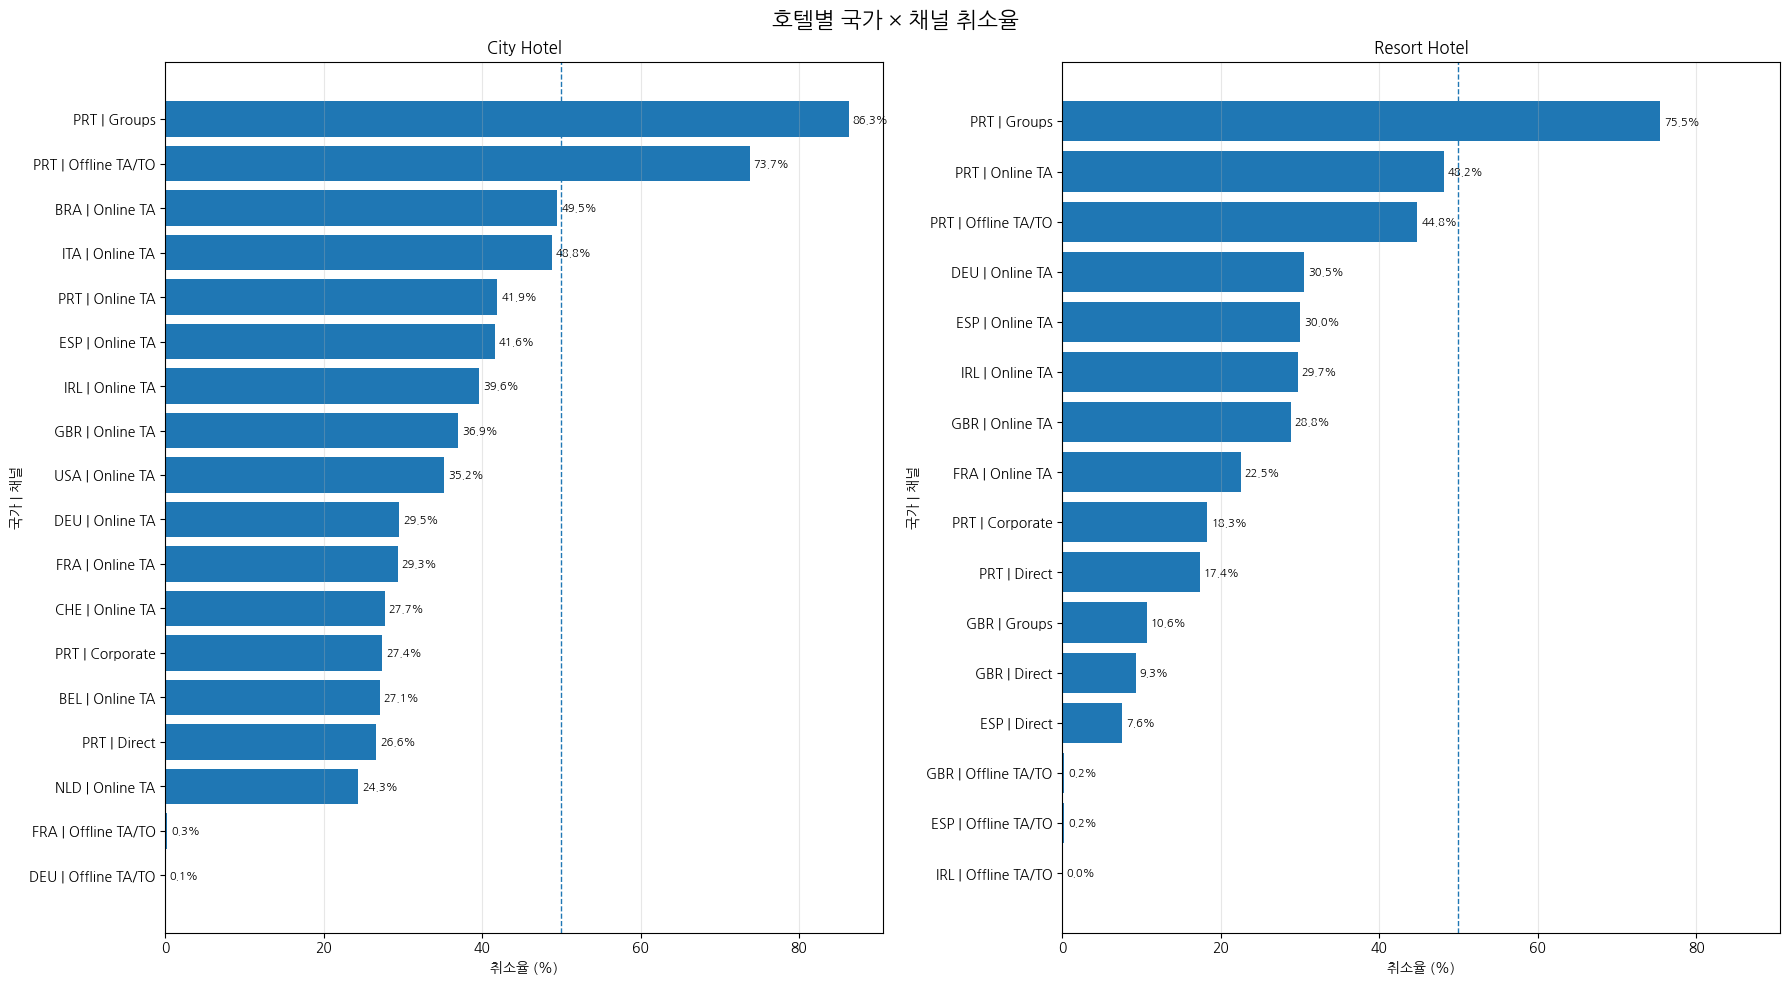

In [ ]:
# ------------------------------------------------------------
# 그래프용
# ------------------------------------------------------------
bar_data = (
    country_market_summary
    .reset_index()
    .copy()
)

# ------------------------------------------------------------
# 호텔별 그래프
# ------------------------------------------------------------
hotels = bar_data["hotel"].unique()

fig, axes = plt.subplots(
    1,
    len(hotels),
    figsize=(18, 10),
    sharex=True
)

# 호텔이 하나일 경우 처리
if len(hotels) == 1:
    axes = [axes]


# ------------------------------------------------------------
# 호텔별
# ------------------------------------------------------------
for ax, hotel in zip(axes, hotels):

    hotel_data = bar_data[
        bar_data["hotel"] == hotel
    ].copy()

    # 국가 × 채널
    hotel_data["country_market"] = (
        hotel_data["country"] + " | " +
        hotel_data["market_segment"]
    )

    # 취소율 높은 순
    hotel_data = hotel_data.sort_values(
        "cancel_rate",
        ascending=True
    )


    # --------------------------------------------------------
    # 막대그래프
    # --------------------------------------------------------
    ax.barh(
        hotel_data["country_market"],
        hotel_data["cancel_rate"]
    )


    # --------------------------------------------------------
    # 50% 기준선
    # --------------------------------------------------------
    ax.axvline(
        50,
        linestyle="--",
        linewidth=1
    )


    # --------------------------------------------------------
    # 값 표시
    # --------------------------------------------------------
    for i, value in enumerate(
        hotel_data["cancel_rate"]
    ):

        ax.text(
            value + 0.5,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=8
        )


    # --------------------------------------------------------
    # 제목 / 축
    # --------------------------------------------------------
    ax.set_title(hotel)

    ax.set_xlabel("취소율 (%)")
    ax.set_ylabel("국가 | 채널")

    ax.grid(
        axis="x",
        alpha=0.3
    )


# ------------------------------------------------------------
# 전체 제목
# ------------------------------------------------------------
fig.suptitle(
    "호텔별 국가 × 채널 취소율",
    fontsize=16
)

plt.tight_layout()
plt.show()

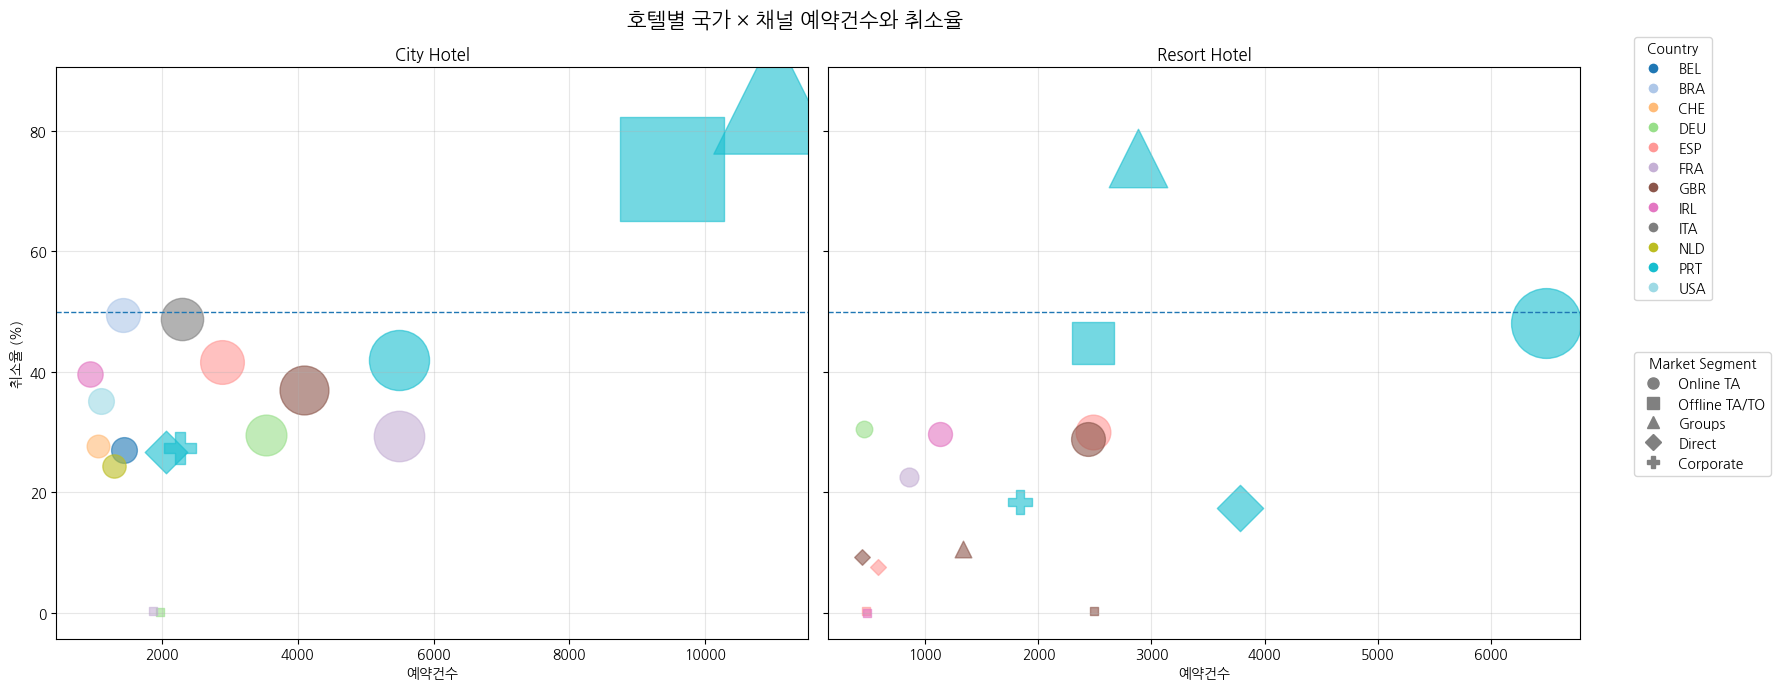

In [ ]:
# ------------------------------------------------------------
# 그래프용 데이터
# ------------------------------------------------------------
plot_data = country_market_summary.reset_index().copy()


# ------------------------------------------------------------
# 국가별 색상
# ------------------------------------------------------------
countries = plot_data["country"].unique()

colors = plt.cm.tab20(
    np.linspace(0, 1, len(countries))
)

country_colors = dict(
    zip(countries, colors)
)


# ------------------------------------------------------------
# 채널별 모양
# ------------------------------------------------------------
markers = {
    "Online TA": "o",
    "Offline TA/TO": "s",
    "Groups": "^",
    "Direct": "D",
    "Corporate": "P",
    "Complementary": "X"
}


# ------------------------------------------------------------
# 호텔별 그래프
# ------------------------------------------------------------
hotels = plot_data["hotel"].unique()

fig, axes = plt.subplots(
    1,
    len(hotels),
    figsize=(16, 7),
    sharey=True
)

# 호텔이 하나일 경우에도 처리
if len(hotels) == 1:
    axes = [axes]


# ------------------------------------------------------------
# 호텔별 산점도
# ------------------------------------------------------------
for ax, hotel in zip(axes, hotels):

    hotel_data = plot_data[
        plot_data["hotel"] == hotel
    ]

    # 국가 × 채널
    for (country, market), group in hotel_data.groupby(
        ["country", "market_segment"]
    ):

        ax.scatter(
            group["reservation_count"],
            group["cancel_rate"],

            # 취소건수 = 원 크기
            s=group["cancel_count"] * 0.8 + 30,

            # 국가 = 색
            color=country_colors[country],

            # 채널 = 모양
            marker=markers.get(market, "o"),

            alpha=0.6
        )

    # --------------------------------------------------------
    # 취소율 50% 기준선
    # --------------------------------------------------------
    ax.axhline(
        50,
        linestyle="--",
        linewidth=1
    )

    # --------------------------------------------------------
    # 제목
    # --------------------------------------------------------
    ax.set_title(hotel)

    ax.set_xlabel("예약건수")
    ax.grid(True, alpha=0.3)


axes[0].set_ylabel("취소율 (%)")


# ------------------------------------------------------------
# 국가 범례
# ------------------------------------------------------------
from matplotlib.lines import Line2D

country_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=country_colors[country],
        markersize=8,
        label=country
    )
    for country in countries
]


# ------------------------------------------------------------
# 채널 범례
# ------------------------------------------------------------
market_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        color="gray",
        linestyle="None",
        markersize=8,
        label=market
    )
    for market, marker in markers.items()
    if market in plot_data["market_segment"].unique()
]


# ------------------------------------------------------------
# 범례
# ------------------------------------------------------------
legend1 = fig.legend(
    handles=country_handles,
    bbox_to_anchor=(1.02, 0.95),
    loc="upper left",
    title="Country"
)

fig.legend(
    handles=market_handles,
    bbox_to_anchor=(1.02, 0.50),
    loc="upper left",
    title="Market Segment"
)


plt.suptitle(
    "호텔별 국가 × 채널 예약건수와 취소율",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [ ]:
# 특정국가의 그룹모집건 취소율
country_market_summary = hotel_two_factor_summary(
    df_raw,
    "country",
    "market_segment",
    hotel_baseline,
    min_reservation_rate=1
)

# Groups만 추출
groups_country_summary = country_market_summary[
    country_market_summary.index.get_level_values("market_segment") == "Groups"
]

# 호텔별 → 예약건수 많은 순
groups_country_summary = groups_country_summary.sort_values(
    ["hotel", "reservation_count"],
    ascending=[True, False]
)

groups_country_summary

reservation_count  cancel_count  \
hotel        country market_segment                                    
City Hotel   PRT     Groups                      11008          9497   
Resort Hotel PRT     Groups                       2885          2177   
             GBR     Groups                       1334           142   

                                     cancel_rate  hotel_baseline_rate  \
hotel        country market_segment                                     
City Hotel   PRT     Groups                86.27                41.73   
Resort Hotel PRT     Groups                75.46                27.76   
             GBR     Groups                10.64                27.76   

                                     cancel_rate_diff  reservation_rate  
hotel        country market_segment                                      
City Hotel   PRT     Groups                     44.54             13.88  
Resort Hotel PRT     Groups                     47.70              7.29  
             GBR     Groups                    -17.12              3.37

In [ ]:
# -------------------
# 호텔별 Groups 예약 취소
# -------------------

hotel_groups_summary = (
    df_raw
    .groupby("hotel")
    .agg(
        total_reservation_count=("is_canceled", "count"),
        groups_reservation_count=("market_segment", lambda x: (x == "Groups").sum()),
        groups_cancel_count=("is_canceled", lambda x: (
            x[df_raw.loc[x.index, "market_segment"] == "Groups"].sum()
        ))
    )
)

# Groups 예약 취소율
hotel_groups_summary["groups_cancel_rate"] = (
    hotel_groups_summary["groups_cancel_count"]
    / hotel_groups_summary["groups_reservation_count"]
    * 100
).round(2)

hotel_groups_summary

,total_reservation_count,groups_reservation_count,groups_cancel_count,groups_cancel_rate
hotel,,,,
City Hotel,79330,13975,9623,68.86
Resort Hotel,40060,5836,2474,42.39


In [ ]:
# -------------------
# City Hotel의 Groups 예약
# PRT / 비PRT 비교
# -------------------

city_groups = df_raw[
    (df_raw["hotel"] == "City Hotel") &
    (df_raw["market_segment"] == "Groups")
]

# PRT Groups
city_prt_groups = city_groups[
    city_groups["country"] == "PRT"
]

# 비PRT Groups
city_non_prt_groups = city_groups[
    city_groups["country"] != "PRT"
]


# -------------------
# 예약건수 / 취소건수
# -------------------

city_groups_compare = pd.DataFrame({
    "reservation_count": [
        len(city_groups),
        len(city_prt_groups),
        len(city_non_prt_groups)
    ],
    "cancel_count": [
        city_groups["is_canceled"].sum(),
        city_prt_groups["is_canceled"].sum(),
        city_non_prt_groups["is_canceled"].sum()
    ]
}, index=[
    "Groups 전체",
    "PRT + Groups",
    "비PRT + Groups"
])


# -------------------
# 취소율
# -------------------

city_groups_compare["cancel_rate"] = (
    city_groups_compare["cancel_count"]
    / city_groups_compare["reservation_count"]
    * 100
).round(2)


city_groups_compare

,reservation_count,cancel_count,cancel_rate
Groups 전체,13975,9623,68.86
PRT + Groups,11008,9497,86.27
비PRT + Groups,2967,126,4.25


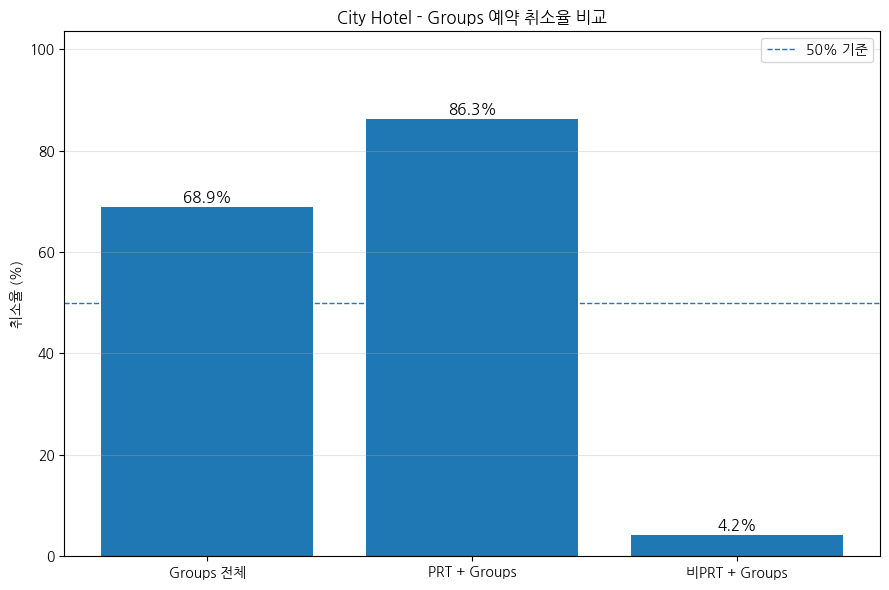

In [ ]:
# ------------------------------------------------------------
# City Hotel - Groups 취소율 비교
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    city_groups_compare.index,
    city_groups_compare["cancel_rate"]
)

# ------------------------------------------------------------
# 50% 기준선
# ------------------------------------------------------------
ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
    label="50% 기준"
)

# ------------------------------------------------------------
# 취소율 표시
# ------------------------------------------------------------
for bar, value in zip(
    bars,
    city_groups_compare["cancel_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

# ------------------------------------------------------------
# 축 / 제목
# ------------------------------------------------------------
ax.set_ylabel("취소율 (%)")

ax.set_title(
    "City Hotel - Groups 예약 취소율 비교"
)

ax.set_ylim(
    0,
    max(city_groups_compare["cancel_rate"]) * 1.2
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

### lead time  분석
- 예약취소에 lead time이 가장 영향도가 높음
- lead time별로  예약 집단 분석 ( market_segment 와 lead time의 상관관계확인)

In [ ]:
# ============================================================
# Lead Time 단일 Factor 분석
# ※ df_raw를 이용
# ※ 원본 df_raw는 변경하지 않음
# ============================================================

lead_data = df_raw.copy()


# ============================================================
# 1. Lead Time 구간 생성
# ============================================================

lead_data["lead_time_group"] = pd.cut(
    lead_data["lead_time"],
    bins=[
        -1,
        7,
        30,
        60,
        90,
        180,
        np.inf
    ],
    labels=[
        "0~7",
        "8~30",
        "31~60",
        "61~90",
        "91~180",
        "181+"
    ]
)


# ============================================================
# 2. Lead Time × 호텔별 예약 / 취소 집계
# ============================================================

lead_summary = (
    lead_data
    .groupby(
        ["hotel", "lead_time_group"],
        observed=True
    )
    .agg(
        reservation_count=("is_canceled", "count"),
        cancel_count=("is_canceled", "sum")
    )
    .reset_index()
)


# ============================================================
# 3. 취소율
# ============================================================

lead_summary["cancel_rate"] = (
    lead_summary["cancel_count"]
    / lead_summary["reservation_count"]
    * 100
).round(2)


# ============================================================
# 4. Lead Time 순서
# ============================================================

lead_order = {
    "0~7": 1,
    "8~30": 2,
    "31~60": 3,
    "61~90": 4,
    "91~180": 5,
    "181+": 6
}

lead_summary["lead_order"] = (
    lead_summary["lead_time_group"]
    .astype(str)
    .map(lead_order)
)


# ============================================================
# 5. 정렬
# ============================================================

lead_summary = (
    lead_summary
    .sort_values(
        ["hotel", "lead_order"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 6. 결과
# ============================================================

lead_summary

,hotel,lead_time_group,reservation_count,cancel_count,cancel_rate,lead_order
0,City Hotel,0~7,10808,1319,12.20,1
1,City Hotel,8~30,12554,3880,30.91,2
2,City Hotel,31~60,11889,4608,38.76,3
3,City Hotel,61~90,8908,3692,41.45,4
4,City Hotel,91~180,18223,8746,47.99,5
5,City Hotel,181+,16948,10857,64.06,6
6,Resort Hotel,0~7,8938,583,6.52,1
7,Resort Hotel,8~30,6406,1403,21.90,2
8,Resort Hotel,31~60,5081,1566,30.82,3
9,Resort Hotel,61~90,3675,1275,34.69,4


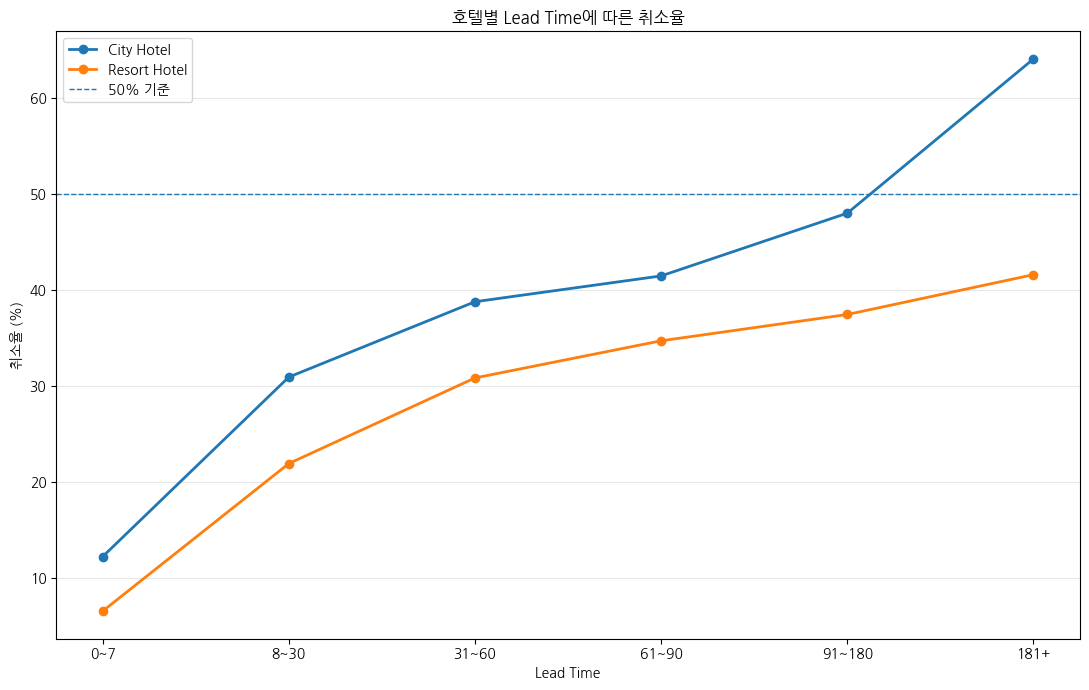

In [ ]:

# ============================================================
# Lead Time × 호텔별 취소율
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))


# ------------------------------------------------------------
# 호텔별 선 그래프
# ------------------------------------------------------------

for hotel, group in lead_summary.groupby("hotel"):

    ax.plot(
        group["lead_time_group"].astype(str),
        group["cancel_rate"],
        marker="o",
        linewidth=2,
        label=hotel
    )


# ------------------------------------------------------------
# 50% 기준선
# ------------------------------------------------------------

ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
    label="50% 기준"
)


# ------------------------------------------------------------
# 축
# ------------------------------------------------------------

ax.set_xlabel("Lead Time")
ax.set_ylabel("취소율 (%)")

ax.set_title(
    "호텔별 Lead Time에 따른 취소율"
)


# ------------------------------------------------------------
# 격자
# ------------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.3
)


# ------------------------------------------------------------
# 범례
# ------------------------------------------------------------

ax.legend()


plt.tight_layout()
plt.show()

In [ ]:
# -------------------
# 1. 호텔별 기초자료
# -------------------

hotel_baseline = (
    df_raw
    .groupby("hotel")["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)

hotel_baseline["cancel_rate"] = (
    hotel_baseline["cancel_count"]
    / hotel_baseline["reservation_count"]
    * 100
).round(2)

hotel_baseline

,reservation_count,cancel_count,cancel_rate
hotel,,,
City Hotel,79330,33102,41.73
Resort Hotel,40060,11122,27.76


In [ ]:
# -------------------
# Lead Time 분석용 copy
# -------------------

lead_market_data = df_raw.copy()

lead_market_data["lead_time_group"] = pd.cut(
    lead_market_data["lead_time"],
    bins=[
        -1,
        7,
        30,
        60,
        90,
        180,
        float("inf")
    ],
    labels=[
        "0~7",
        "8~30",
        "31~60",
        "61~90",
        "91~180",
        "181+"
    ],
    ordered=True
)
# -------------------
# 3. Lead Time + Market Segment
# -------------------

lead_market_summary = hotel_two_factor_summary(
    lead_market_data,
    "lead_time_group",
    "market_segment",
    hotel_baseline=hotel_baseline,
    min_reservation_rate=1
)

lead_market_summary

/tmp/ipykernel_44449/2906995871.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["hotel", factor1, factor2])["is_canceled"]


reservation_count  cancel_count  \
hotel        lead_time_group market_segment                                    
City Hotel   0~7             Corporate                    1386           138   
                             Direct                       2291           248   
                             Offline TA/TO                1160           189   
                             Online TA                    4981           580   
             8~30            Corporate                     849           139   
                             Direct                       1200           250   
                             Groups                       1027           406   
                             Offline TA/TO                1670           418   
                             Online TA                    7680          2644   
             31~60           Groups                       1395           636   
                             Offline TA/TO                2582           935   
                             Online TA                    6851          2732   
             61~90           Groups                       1590          1007   
                             Offline TA/TO                1703           577   
                             Online TA                    4919          1937   
             91~180          Direct                       1007           194   
                             Groups                       3083          2127   
                             Offline TA/TO                4470          2223   
                             Online TA                    9423          4057   
             181+            Groups                       6493          5372   
                             Offline TA/TO                5162          2831   
                             Online TA                    4894          2541   
Resort Hotel 0~7             Corporate                    1356           101   
                             Direct                       2967           171   
                             Offline TA/TO                 859            45   
                             Online TA                    3363           215   
             8~30            Corporate                     515            97   
                             Direct                       1099           197   
                             Groups                        530           129   
                             Offline TA/TO                 951           114   
                             Online TA                    3248           855   
             31~60           Direct                        675           131   
                             Groups                        519           162   
                             Offline TA/TO                 883            90   
                             Online TA                    2726          1066   
             61~90           Direct                        469            86   
                             Groups                        446           261   
                             Offline TA/TO                 658           101   
                             Online TA                    1961           788   
             91~180          Direct                        811           158   
                             Groups                       1466           768   
                             Offline TA/TO                2070           291   
                             Online TA                    3828          1849   
             181+            Direct                        492           135   
                             Groups                       2582          1113   
                             Offline TA/TO                2051           497   
                             Online TA                    2603          1475   

                                             cancel_rate  hotel_baseline_rate  \
hotel        lead_time_group market_segment

/tmp/ipykernel_44449/2172637295.py:42: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = group.pivot_table(


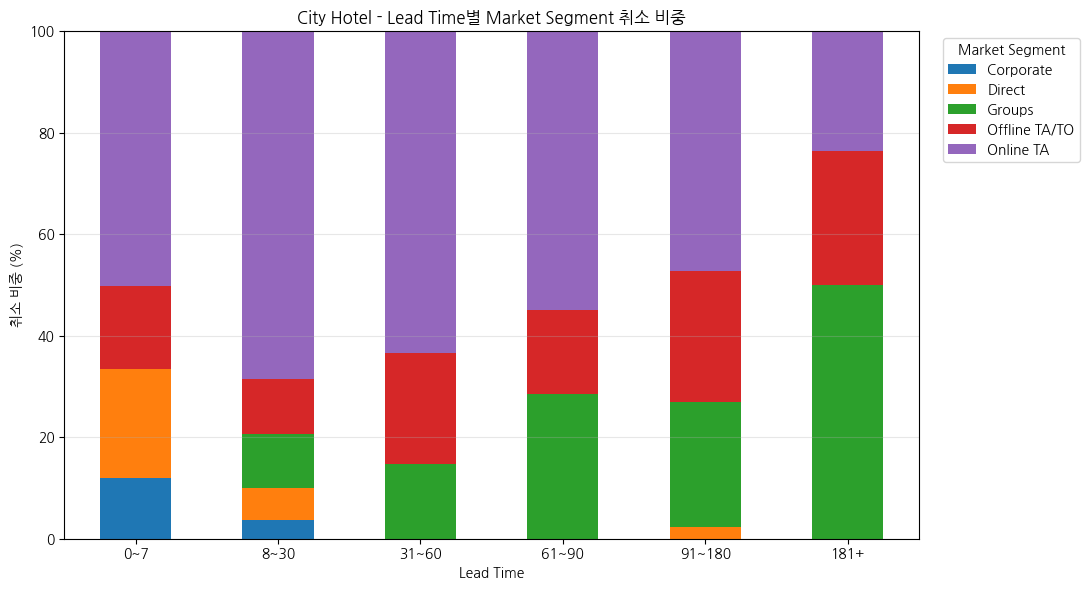

/tmp/ipykernel_44449/2172637295.py:42: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = group.pivot_table(


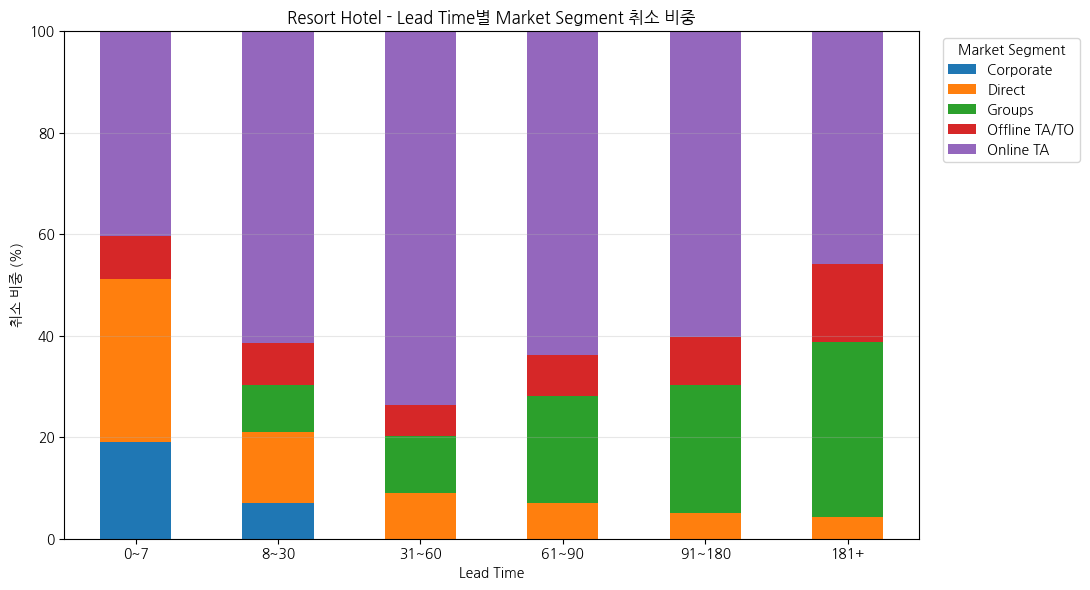

In [ ]:
# ============================================================
# 데이터
# ============================================================

plot_data = (
    lead_market_summary
    .reset_index()
    .copy()
)


# ============================================================
# Lead Time 순서
# ============================================================

lead_order = [
    "0~7",
    "8~30",
    "31~60",
    "61~90",
    "91~180",
    "181+"
]

plot_data["lead_time_group"] = pd.Categorical(
    plot_data["lead_time_group"],
    categories=lead_order,
    ordered=True
)


# ============================================================
# 호텔별 그래프
# ============================================================

for hotel, group in plot_data.groupby("hotel"):

    # --------------------------------------------------------
    # Lead Time × Market Segment 취소건수
    # --------------------------------------------------------

    pivot = group.pivot_table(
        index="lead_time_group",
        columns="market_segment",
        values="cancel_count",
        aggfunc="sum",
        fill_value=0
    )

    pivot = pivot.reindex(lead_order)


    # --------------------------------------------------------
    # Lead Time별 취소 비중
    # --------------------------------------------------------

    pivot_rate = (
        pivot
        .div(pivot.sum(axis=1), axis=0)
        * 100
    )


    # --------------------------------------------------------
    # 100% 누적 막대그래프
    # --------------------------------------------------------

    ax = pivot_rate.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6)
    )


    # --------------------------------------------------------
    # 축
    # --------------------------------------------------------

    ax.set_title(
        f"{hotel} - Lead Time별 Market Segment 취소 비중"
    )

    ax.set_xlabel("Lead Time")
    ax.set_ylabel("취소 비중 (%)")

    ax.set_ylim(0, 100)

    ax.grid(
        axis="y",
        alpha=0.3
    )

    ax.legend(
        title="Market Segment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_44449/674444719.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_cancel_rate = group.pivot_table(


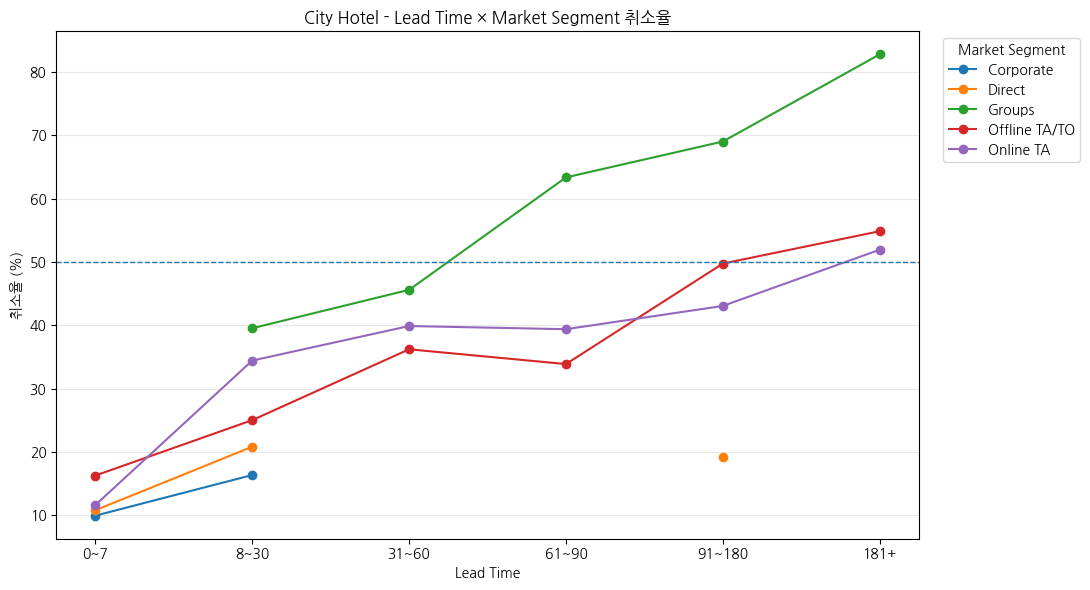

/tmp/ipykernel_44449/674444719.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_cancel_rate = group.pivot_table(


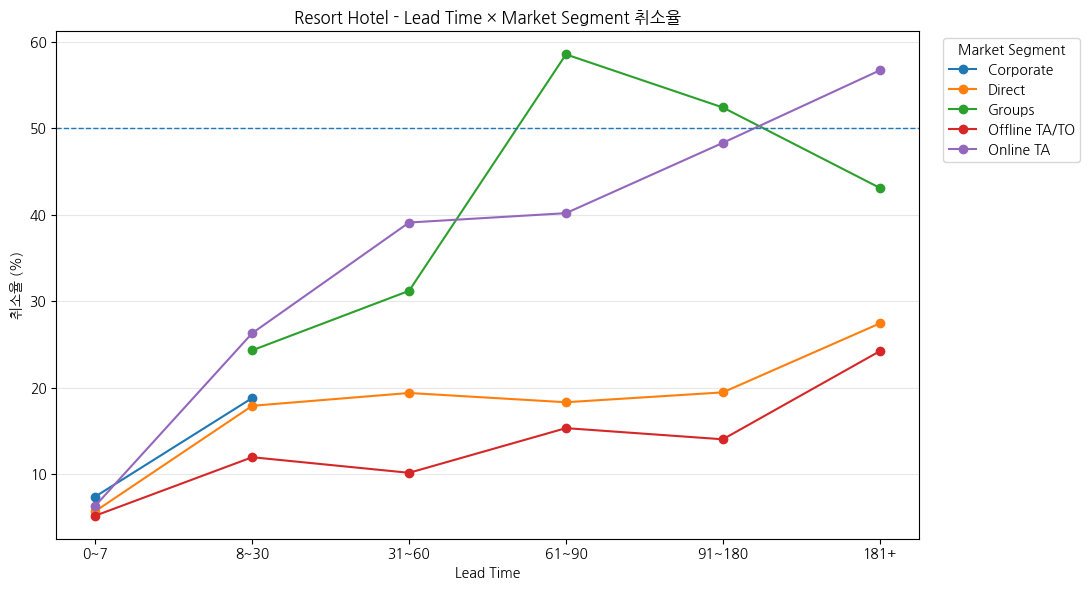

In [ ]:
# ============================================================
# 추가 그래프
# Lead Time × Market Segment 취소율
# ============================================================

for hotel, group in plot_data.groupby("hotel"):

    # --------------------------------------------------------
    # Lead Time × Market Segment
    # 취소율
    # --------------------------------------------------------

    pivot_cancel_rate = group.pivot_table(
        index="lead_time_group",
        columns="market_segment",
        values="cancel_rate",
        aggfunc="mean"
    )

    pivot_cancel_rate = pivot_cancel_rate.reindex(
        lead_order
    )

    # --------------------------------------------------------
    # 그래프
    # --------------------------------------------------------

    ax = pivot_cancel_rate.plot(
        kind="line",
        marker="o",
        figsize=(11, 6)
    )

    # --------------------------------------------------------
    # 제목
    # --------------------------------------------------------

    ax.set_title(
        f"{hotel} - Lead Time × Market Segment 취소율"
    )

    # --------------------------------------------------------
    # 축
    # --------------------------------------------------------

    ax.set_xlabel("Lead Time")
    ax.set_ylabel("취소율 (%)")

    # --------------------------------------------------------
    # 기준선
    # --------------------------------------------------------

    ax.axhline(
        50,
        linestyle="--",
        linewidth=1
    )

    # --------------------------------------------------------
    # 격자
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        alpha=0.3
    )

    # --------------------------------------------------------
    # 범례
    # --------------------------------------------------------

    ax.legend(
        title="Market Segment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [ ]:

#-----------------------------
# lead time > 60일 이상 채널별 예약, 취소 정보 --> 취소율이 높은 long lead time 주요예약 경로 확인
#  -
#-----------------------------
def long_lead_summary(df):
    result = (
        df
        .assign(long_lead=df["lead_time"] >= 60)
        .groupby(["hotel", "market_segment"])
        .agg(
            reservation_count=("is_canceled", "count"),
            long_lead_count=("long_lead", "sum"),
            cancel_count=("is_canceled", "sum")
        )
    )

    result["long_lead_ratio"] = (
        result["long_lead_count"]
        / result["reservation_count"]
        * 100
    ).round(2)

    result["cancel_rate"] = (
        result["cancel_count"]
        / result["reservation_count"]
        * 100
    ).round(2)

    return result

In [ ]:
summary_all = long_lead_summary(df_raw)

summary_all

reservation_count  long_lead_count  cancel_count  \
hotel        market_segment                                                     
City Hotel   Aviation                      237                0            52   
             Complementary                 542               25            64   
             Corporate                    2986              431           641   
             Direct                       6093             1914          1056   
             Groups                      13975            11166          9623   
             Offline TA/TO               16747            11420          7173   
             Online TA                   38748            19420         14491   
             Undefined                       2                0             2   
Resort Hotel Complementary                 201               19            33   
             Corporate                    2309              190           351   
             Direct                       6513             1786           878   
             Groups                       5836             4498          2474   
             Offline TA/TO                7472             4795          1138   
             Online TA                   17729             8486          6248   

                             long_lead_ratio  cancel_rate  
hotel        market_segment                                
City Hotel   Aviation                   0.00        21.94  
             Complementary              4.61        11.81  
             Corporate                 14.43        21.47  
             Direct                    31.41        17.33  
             Groups                    79.90        68.86  
             Offline TA/TO             68.19        42.83  
             Online TA                 50.12        37.40  
             Undefined                  0.00       100.00  
Resort Hotel Complementary              9.45        16.42  
             Corporate                  8.23        15.20  
             Direct                    27.42        13.48  
             Groups                    77.07        42.39  
             Offline TA/TO             64.17        15.23  
             Online TA                 47.87        35.24

In [ ]:
#-----------------------------
# 위 데이터 근거로 lead time > 60 & 특정채널 ( on/off , group ) 이 높은 사유 추정
#  - 채널과 관련있는 agent정보 추가분석 (실측정보는 unknown으로 일괄처리)
#  - 복사본으로 진행
#-----------------------------

# # ------------------------------------------------------------
# # 1. PRT 제외
# # ------------------------------------------------------------
# file_no_prt = df_raw[
#     df_raw["country"] != "PRT"
# ].copy()

# ------------------------------------------------------------
# 1. 분석용 복사본
# ------------------------------------------------------------
file_leadtime = df_raw.copy()

# ------------------------------------------------------------
# 2. Lead Time 구간 생성
# ------------------------------------------------------------
bins = [-1, 7, 30, 60, 90, 180, float("inf")]

labels = [
    "0~7일",
    "8~30일",
    "31~60일",
    "61~90일",
    "91~180일",
    "181일+"
]

file_leadtime["lead_time_group"] = pd.cut(
    file_leadtime["lead_time"],
    bins=bins,
    labels=labels
)


# ------------------------------------------------------------
# 3. 호텔별 전체 Baseline
# ------------------------------------------------------------
hotel_baseline = (
    file_leadtime
    .groupby("hotel")["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)

hotel_baseline["cancel_rate"] = (
    hotel_baseline["cancel_count"]
    / hotel_baseline["reservation_count"]
    * 100
).round(2)


# ------------------------------------------------------------
# 4. 채널 + Lead Time 분석
# ------------------------------------------------------------
lead_channel_summary = (
    file_leadtime
    .groupby(
        ["hotel", "market_segment", "lead_time_group"],
        observed=True
    )["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)


# ------------------------------------------------------------
# 5. 해당 채널 + Lead Time 구간의 취소율
# ------------------------------------------------------------
lead_channel_summary["cancel_rate"] = (
    lead_channel_summary["cancel_count"]
    / lead_channel_summary["reservation_count"]
    * 100
).round(2)


# ------------------------------------------------------------
# 6. 호텔 전체 Baseline 취소율
# ------------------------------------------------------------
lead_channel_summary["hotel_baseline_rate"] = (
    lead_channel_summary
    .index
    .get_level_values("hotel")
    .map(hotel_baseline["cancel_rate"])
)


# ------------------------------------------------------------
# 7. 호텔 평균 대비 취소율 차이
# ------------------------------------------------------------
lead_channel_summary["cancel_rate_diff"] = (
    lead_channel_summary["cancel_rate"]
    - lead_channel_summary["hotel_baseline_rate"]
).round(2)


# ------------------------------------------------------------
# 8. 호텔 전체 예약 대비 예약 비중
# ------------------------------------------------------------
lead_channel_summary["reservation_rate"] = (
    lead_channel_summary["reservation_count"]
    /
    lead_channel_summary
    .index
    .get_level_values("hotel")
    .map(hotel_baseline["reservation_count"])
    * 100
).round(2)


# ------------------------------------------------------------
# 9. 결과
# ------------------------------------------------------------
lead_channel_summary

reservation_count  cancel_count  \
hotel        market_segment lead_time_group                                    
City Hotel   Aviation       0~7일                           191            39   
                            8~30일                           46            13   
             Complementary  0~7일                           410            48   
                            8~30일                           82            10   
                            31~60일                          25             2   
                            61~90일                          13             4   
                            91~180일                          9             0   
                            181일+                            3             0   
             Corporate      0~7일                          1386           138   
                            8~30일                          849           139   
                            31~60일                         323           132   
                            61~90일                         165            64   
                            91~180일                        231           145   
                            181일+                           32            23   
             Direct         0~7일                          2291           248   
                            8~30일                         1200           250   
                            31~60일                         713           171   
                            61~90일                         518           103   
                            91~180일                       1007           194   
                            181일+                          364            90   
             Groups         0~7일                           387            75   
                            8~30일                         1027           406   
                            31~60일                        1395           636   
                            61~90일                        1590          1007   
                            91~180일                       3083          2127   
                            181일+                         6493          5372   
             Offline TA/TO  0~7일                          1160           189   
                            8~30일                         1670           418   
                            31~60일                        2582           935   
                            61~90일                        1703           577   
                            91~180일                       4470          2223   
                            181일+                         5162          2831   
             Online TA      0~7일                          4981           580   
                            8~30일                         7680          2644   
                            31~60일                        6851          2732   
                            61~90일                        4919          1937   
                            91~180일                       9423          4057   
                            181일+                         4894          2541   
             Undefined      0~7일                             2             2   
Resort Hotel Complementary  0~7일                           100            10   
                            8~30일                           63            11   
                            31~60일                          19             5   
                            61~90일                           9             3   
                            91~180일                          9             4   
                            181일+                            1             0   
             Corporate      0~7일                          1356           101   
                            8~30일                          515            97   
                            31~60일                         259           112   
                            61~90일           

In [ ]:
# ============================================================
# 장기예약(lead_time >= 60일) × 채널별 Agent 분석
# NaN Agent → "Unknown" 그룹 처리
# - 특정 agent에 취소율이 높음
# ============================================================

# # ------------------------------------------------------------
# # 1. 자료복사
# # ------------------------------------------------------------
# file_leadtime_long = df_raw.copy()


# ------------------------------------------------------------
# 2. 장기예약만 추출
# ------------------------------------------------------------
long_lead = file_leadtime[
    file_leadtime["lead_time"] >= 60
].copy()


# ------------------------------------------------------------
# 3. Agent 결측치 처리
# ------------------------------------------------------------
long_lead["agent_group"] = (
    long_lead["agent"]
    .fillna("Unknown")
    .astype(str)
)


# ------------------------------------------------------------
# 4. 채널 × Agent별 예약 / 취소 집계
# ------------------------------------------------------------
agent_summary = (
    long_lead
    .groupby(
        ["hotel", "market_segment", "agent_group"]
    )["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)


# ------------------------------------------------------------
# 5. Agent별 취소율
# ------------------------------------------------------------
agent_summary["cancel_rate"] = (
    agent_summary["cancel_count"]
    / agent_summary["reservation_count"]
    * 100
).round(2)


# ------------------------------------------------------------
# 6. 채널 내 Agent 예약 비율
# ------------------------------------------------------------
channel_total = (
    agent_summary
    .groupby(
        ["hotel", "market_segment"]
    )["reservation_count"]
    .transform("sum")
)

agent_summary["channel_reservation_rate"] = (
    agent_summary["reservation_count"]
    / channel_total
    * 100
).round(2)


# ------------------------------------------------------------
# 7. 호텔 전체 장기예약 대비 비율
# ------------------------------------------------------------
hotel_long_total = (
    agent_summary
    .groupby(level="hotel")["reservation_count"]
    .transform("sum")
)

agent_summary["hotel_long_reservation_rate"] = (
    agent_summary["reservation_count"]
    / hotel_long_total
    * 100
).round(2)


# agent_summary = agent_summary[
#     (( agent_summary["reservation_count"] > 10 ) & ( agent_summary["cancel_rate"] > 10 )
#     & (agent_summary["hotel_long_reservation_rate"] >= 1))
# ].copy()


# ------------------------------------------------------------
# 8. 결과 정렬
# ------------------------------------------------------------
agent_summary = (
    agent_summary
    .sort_values(
        ["hotel", "market_segment", "reservation_count"],
        ascending=[True, True, False]
    )
)


agent_summary.head()
# agent_summary


reservation_count  cancel_count  \
hotel      market_segment agent_group                                    
City Hotel Complementary  Unknown                     23             4   
                          12.0                         1             0   
                          6.0                          1             0   
           Corporate      Unknown                    400           227   
                          193.0                       12             0   

                                       cancel_rate  channel_reservation_rate  \
hotel      market_segment agent_group                                          
City Hotel Complementary  Unknown            17.39                     92.00   
                          12.0                0.00                      4.00   
                          6.0                 0.00                      4.00   
           Corporate      Unknown            56.75                     92.81   
                          193.0               0.00                      2.78   

                                       hotel_long_reservation_rate  
hotel      market_segment agent_group                               
City Hotel Complementary  Unknown                             0.05  
                          12.0                                0.00  
                          6.0                                 0.00  
           Corporate      Unknown                             0.90  
                          193.0                               0.03

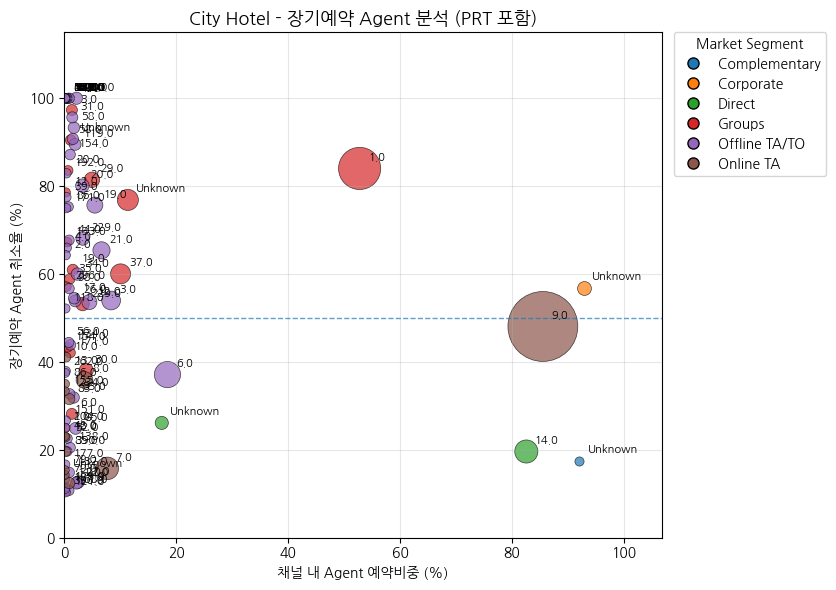

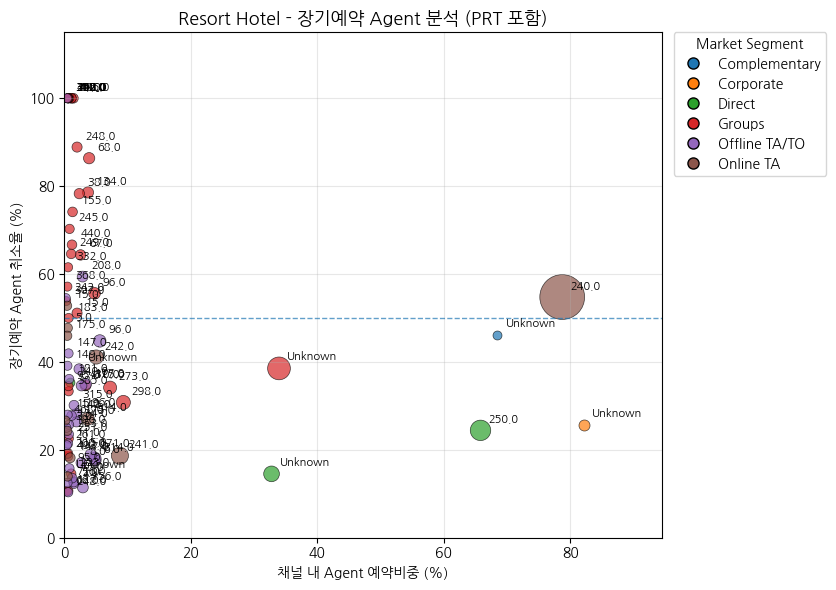

In [ ]:
# ============================================================
# 장기예약 Agent 분석 그래프 -
# ------------------------------------------------------------
# 1. Lead Time >= 60
# 2. reservation_count > 10
# 3. cancel_rate > 10
# 4. channel_reservation_rate > 5%
#
# 그래프
# ------------------------------------------------------------
# X축 : 채널 내 Agent 예약비중
# Y축 : 장기예약 Agent 취소율
# 원 크기 : 예약건수
# 원 색상 : Market Segment
# 범례 : 그래프 밖
#
# ※ 원본 df_raw / agent_summary는 수정하지 않음
# ============================================================
# ============================================================
# 1. 자료복사
# ============================================================

agent_data = long_lead.copy()


# ============================================================
# 3. Agent 결측치 처리
# ============================================================

agent_data["agent_group"] = (
    agent_data["agent"]
    .fillna("Unknown")
    .astype(str)
)


# ============================================================
# 4. 호텔 × Market Segment × Agent 집계
# ============================================================

agent_summary_all = (
    agent_data
    .groupby(
        [
            "hotel",
            "market_segment",
            "agent_group"
        ]
    )["is_canceled"]
    .agg(
        reservation_count="count",
        cancel_count="sum"
    )
)

# ============================================================
# 5. Agent별 취소율
# ============================================================

agent_summary_all["cancel_rate"] = (
    agent_summary_all["cancel_count"]
    / agent_summary_all["reservation_count"]
    * 100
).round(2)


# ============================================================
# 6. 채널 내 Agent 예약비중
# ============================================================

channel_total = (
    agent_summary_all
    .groupby(
        [
            "hotel",
            "market_segment"
        ]
    )["reservation_count"]
    .transform("sum")
)


agent_summary_all["channel_reservation_rate"] = (
    agent_summary_all["reservation_count"]
    / channel_total
    * 100
).round(2)

# ============================================================
# 7. 호텔 전체 장기예약 대비 Agent 예약비중
# ============================================================

hotel_long_total = (
    agent_summary_all
    .groupby(
        level="hotel"
    )["reservation_count"]
    .transform("sum")
)

agent_summary_all["hotel_long_reservation_rate"] = (
    agent_summary_all["reservation_count"]
    / hotel_long_total
    * 100
).round(2)

# ============================================================
# 8. Agent 분석 대상 필터
#
# reservation_count > 10
# cancel_rate > 10
# ============================================================

agent_summary_all = agent_summary_all[
    (
        (agent_summary_all["reservation_count"] > 10)
        &
        (agent_summary_all["cancel_rate"] > 10)
    )
].copy()

# ============================================================
# 9. 정렬
# ============================================================

agent_summary_all = (
    agent_summary_all
    .sort_values(
        [
            "hotel",
            "market_segment",
            "reservation_count"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)

# ============================================================
# 10. 그래프용 데이터
# ============================================================

plot_data = (
    agent_summary_all
    .reset_index()
    .copy()
)

# ============================================================
# 11. 채널 내 예약비중 5% 초과만 그래프에 표시
#
# ※ agent_summary_all 자체는 그대로 유지
# ============================================================

# plot_data = plot_data[
#     plot_data["channel_reservation_rate"] > 5
# ].copy()


# ============================================================
# 12. Market Segment별 색상 고정
#
# 호텔이 달라도 같은 Market Segment는 같은 색
# ============================================================

segments = sorted(
    plot_data["market_segment"]
    .dropna()
    .unique()
)

colors = plt.cm.tab10.colors

color_map = {
    segment: colors[i % len(colors)]
    for i, segment in enumerate(segments)
}


# ============================================================
# 13. 호텔별 그래프
# ============================================================

for hotel, group in plot_data.groupby("hotel"):

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    # ========================================================
    # Market Segment별 산점도
    # ========================================================

    for segment, data in group.groupby("market_segment"):

        ax.scatter(
            data["channel_reservation_rate"],
            data["cancel_rate"],

            # 예약건수 → 원 크기
            s=data["reservation_count"] * 0.15 + 40,
            # Market Segment → 색상
            color=color_map[segment],
            alpha=0.7,
            edgecolors="black",
            linewidths=0.5
        )


        # ====================================================
        # Agent 번호 표시
        # ====================================================

        for _, row in data.iterrows():

            ax.annotate(
                row["agent_group"],

                (
                    row["channel_reservation_rate"],
                    row["cancel_rate"]
                ),

                xytext=(6, 6),
                textcoords="offset points",
                fontsize=8
            )

    # ========================================================
    # 14. 50% 취소율 기준선
    # ========================================================

    ax.axhline(
        50,
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

    # ========================================================
    # 15. 축
    # ========================================================

    ax.set_xlabel(
        "채널 내 Agent 예약비중 (%)"
    )

    ax.set_ylabel(
        "장기예약 Agent 취소율 (%)"
    )

    # ========================================================
    # 16. 축 범위
    # ========================================================

    x_max = group[
        "channel_reservation_rate"
    ].max()

    y_max = group[
        "cancel_rate"
    ].max()


    ax.set_xlim(
        0,
        x_max * 1.15
    )

    ax.set_ylim(
        0,
        max(100, y_max * 1.15)
    )

    # ========================================================
    # 17. 제목
    # ========================================================

    ax.set_title(
        f"{hotel} - 장기예약 Agent 분석 (PRT 포함)",
        fontsize=13
    )

    # ========================================================
    # 18. 격자
    # ========================================================

    ax.grid(
        True,
        alpha=0.3
    )

    # ========================================================
    # 19. 범례 생성
    #
    # 실제 원 크기와 관계없이
    # 범례의 원 크기는 동일
    # ========================================================

    legend_handles = []

    for segment in segments:

        if segment not in group["market_segment"].values:
            continue

        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=color_map[segment],
                markeredgecolor="black",
                markersize=8,
                label=segment
            )
        )


    # ========================================================
    # 20. 범례 → 그래프 오른쪽
    # ========================================================

    ax.legend(
        handles=legend_handles,
        title="Market Segment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )


    # ========================================================
    # 21. 여백
    # ========================================================

    plt.tight_layout(
        rect=[0, 0, 0.85, 1]
    )

    plt.show()


# ============================================================
# 22. 최종 데이터 확인
# ============================================================

# agent_summary_all

In [ ]:
# ============================================================
# 장기예약 취소건수 상위 20개 Agent
# → 호텔 전체 취소건수 대비 몇 %인지
# ============================================================

# 1. 취소건수 상위 20개
top20_agent = (
    agent_summary
    .sort_values("cancel_count", ascending=False)
    .head(20)
    .copy()
)


# ------------------------------------------------------------
# 2. 호텔별 Top 20 Agent 취소건수 합계
# ------------------------------------------------------------
top20_hotel_cancel = (
    top20_agent
    .groupby(level="hotel")["cancel_count"]
    .sum()
)


# ------------------------------------------------------------
# 3. 호텔 전체 취소건수
# ------------------------------------------------------------
hotel_total_cancel = (
    file_leadtime
    .groupby("hotel")["is_canceled"]
    .sum()
)


# ------------------------------------------------------------
# 4. 호텔 전체 취소건수 대비 Top 20 비율
# ------------------------------------------------------------
top20_compare = (
    top20_hotel_cancel
    .to_frame("top20_cancel_count")
    .join(
        hotel_total_cancel.rename("hotel_total_cancel")
    )
)

top20_compare["top20_vs_hotel_cancel_rate"] = (
    top20_compare["top20_cancel_count"]
    / top20_compare["hotel_total_cancel"]
    * 100
).round(2)


top20_compare

,top20_cancel_count,hotel_total_cancel,top20_vs_hotel_cancel_rate
hotel,,,
City Hotel,19379,33102,58.54
Resort Hotel,4533,11122,40.76


# <font size="6">분석 결과</font>

<font size="6">

| 구분 | City Hotel | Resort Hotel |
|---|---:|---:|
| 호텔 전체 취소율 | **41.73%** | **27.76%** |
| 상위 Agent 취소율* | **23.14%** | **12.72%** |
| 전체 취소 중 상위 Agent 비중 | **55.46%** | **45.83%** |

</font>

<font size="3">
* 상위 Agent 취소건 ÷ 호텔 전체 예약건
</font>

## Lead Time 60일 이상 예약 선행기간을 분석한 결과, 상위 20개 Agent의 취소가 전체 취소의 City Hotel 55.46%, Resort Hotel 45.83%를 차지
## 취소거래가 정상건인지 확인이 필요하며 비정상 거래로 판단될 경우 재발 방지를 위한 관리 및 패널티를 적용하는 한편, 예약 비중과 취소율을 고려한 Agent관리 프로세스를 제안합니다.
### 첨부) 포르투갈(PRT)은 Groups 예약의 취소율이 높고 예약 비중도 크게 나타나 전체 취소율에 영향을 미치는 것으로 확인되어, 일반 국가와 분리한 별도 분석이 필요할 것으로 판단됩니다.

.. 코드는 AI를 참조하고 데이터 분석에 비중을 두었습니다. 통계는 잘몰라서 적용하지 못했습니다. 공부는 따로 할께요. 수고하세요~